# Heart Attack Risk Prediction
## Explainable, Leak-Free Clinical ML Pipeline

A compact clinical ML workflow for binary heart-attack risk prediction.

The focus is simple: audit the data, avoid leakage, validate honestly, and explain the final model.

## 1. Setup

Keep imports centralized and make results reproducible.

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import ExtraTreesClassifier, HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    brier_score_loss,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
TARGET = "heart_attack_risk"
ID_COL = "patient_id"

sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams["figure.figsize"] = (9, 5)
pd.set_option("display.max_columns", 100)

## 2. Load Data

This cell works locally and on Kaggle by searching common CSV locations.

In [2]:
def find_dataset() -> Path:
    candidates = [
        Path("heart_attack_dataset (1).csv"),
        Path("heart_attack_dataset.csv"),
        Path("/kaggle/input/heart-attack-risk-prediction-dataset/heart_attack_dataset.csv"),
        Path("/kaggle/input/heart-attack-risk-prediction-dataset/heart_attack_dataset (1).csv"),
    ]

    for path in candidates:
        if path.exists():
            return path

    search_roots = [Path("/kaggle/input"), Path(".")]
    csv_files = []
    for root in search_roots:
        if root.exists():
            csv_files.extend(root.rglob("*.csv"))

    heart_files = [p for p in csv_files if "heart" in p.name.lower()]
    if heart_files:
        return heart_files[0]
    if csv_files:
        return csv_files[0]

    raise FileNotFoundError("No CSV file found. Attach the dataset or update the path.")


data_path = find_dataset()
df = pd.read_csv(data_path)

print(f"Loaded: {data_path}")
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]:,} columns")
display(df.head())

Loaded: /kaggle/input/datasets/velvetcrystal/heart-attack-risk-prediction-dataset/heart_attack_dataset (1).csv
Shape: 7,000 rows x 22 columns


,patient_id,age,gender,chest_pain_type,resting_bp,cholesterol,fasting_blood_sugar,resting_ecg,max_heart_rate,exercise_angina,oldpeak,st_slope,num_major_vessels,thalassemia,bmi,smoking_status,alcohol_consumption,physical_activity,family_history,diabetes,stress_level,heart_attack_risk
0,1,59,Male,Asymptomatic,105.0,154.0,0.0,ST-T Abnormality,186.0,1,1.0,Flat,1,Fixed Defect,23.5,Former,Heavy,Moderate,1,1,6.0,0
1,2,50,Male,Non-anginal Pain,102.0,180.0,0.0,Normal,183.0,0,2.9,Flat,0,Reversible Defect,19.3,NaN,Moderate,High,0,0,8.0,0
2,3,61,Male,Atypical Angina,117.0,213.0,1.0,Normal,161.0,0,0.0,Flat,1,Fixed Defect,30.5,Never,Moderate,Low,1,1,2.0,1
3,4,73,Female,Atypical Angina,121.0,208.0,1.0,Normal,150.0,0,1.0,Up,0,Normal,28.6,Former,Moderate,Moderate,0,0,4.0,0
4,5,49,Male,Non-anginal Pain,106.0,157.0,0.0,Normal,185.0,0,0.3,Flat,0,Reversible Defect,21.4,Former,Moderate,Moderate,0,0,NaN,0


## 3. Fast Dataset Audit

First check schema, missingness, uniqueness, and target balance.

In [3]:
audit = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing": df.isna().sum(),
    "missing_%": (df.isna().mean() * 100).round(2),
    "unique": df.nunique(dropna=True),
}).sort_values(["missing_%", "unique"], ascending=[False, False])

display(audit)

print(f"Duplicate rows: {df.duplicated().sum():,}")
if ID_COL in df:
    print(f"Duplicate {ID_COL}: {df[ID_COL].duplicated().sum():,}")

target_counts = df[TARGET].value_counts().rename("count").to_frame()
target_counts["rate_%"] = (target_counts["count"] / len(df) * 100).round(2)
display(target_counts)

,dtype,missing,missing_%,unique
smoking_status,object,505,7.21,3
alcohol_consumption,object,405,5.79,3
cholesterol,float64,398,5.69,186
oldpeak,float64,350,5.00,65
physical_activity,object,346,4.94,3
bmi,float64,330,4.71,275
resting_bp,float64,280,4.00,79
max_heart_rate,float64,279,3.99,89
stress_level,float64,268,3.83,10
resting_ecg,object,199,2.84,3


Duplicate rows: 0
Duplicate patient_id: 0


,count,rate_%
heart_attack_risk,,
0,4060,58.0
1,2940,42.0


## 4. Missingness And Target

Missingness is small enough for imputation, but it should happen inside cross-validation.

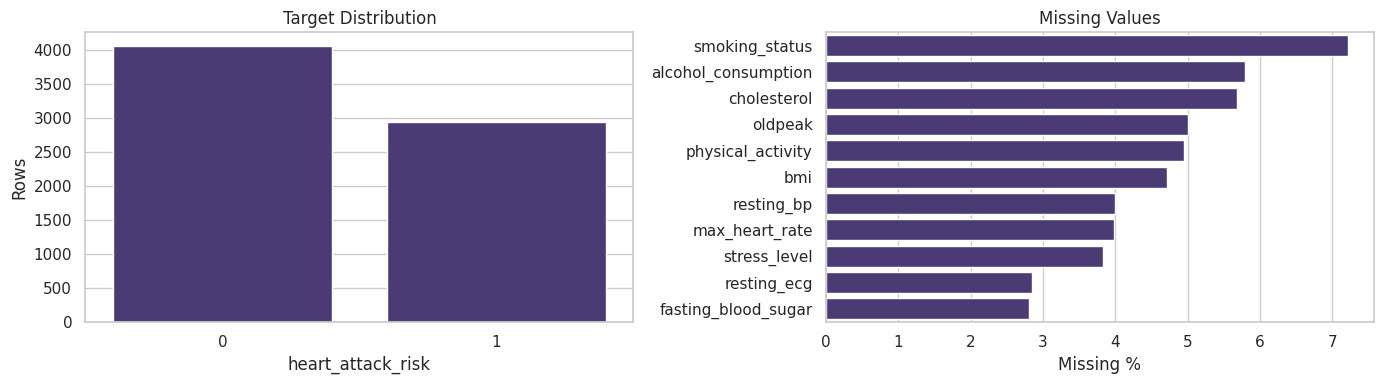

,feature,missing_%,risk_when_missing,risk_when_present
7,smoking_status,7.214,0.410,0.421
8,alcohol_consumption,5.786,0.378,0.423
1,cholesterol,5.686,0.440,0.419
5,oldpeak,5.000,0.414,0.420
9,physical_activity,4.943,0.361,0.423
6,bmi,4.714,0.445,0.419
0,resting_bp,4.000,0.429,0.420
4,max_heart_rate,3.986,0.416,0.420
10,stress_level,3.829,0.433,0.419
3,resting_ecg,2.843,0.457,0.419


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

target_counts = df[TARGET].value_counts().sort_index()
sns.barplot(x=target_counts.index.astype(str), y=target_counts.values, ax=axes[0])
axes[0].set_title("Target Distribution")
axes[0].set_xlabel("heart_attack_risk")
axes[0].set_ylabel("Rows")

missing = df.isna().mean().mul(100).sort_values(ascending=False)
missing = missing[missing > 0]
sns.barplot(x=missing.values, y=missing.index, ax=axes[1])
axes[1].set_title("Missing Values")
axes[1].set_xlabel("Missing %")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

missing_signal = []
for col in df.columns:
    if df[col].isna().any():
        missing_signal.append({
            "feature": col,
            "missing_%": df[col].isna().mean() * 100,
            "risk_when_missing": df.loc[df[col].isna(), TARGET].mean(),
            "risk_when_present": df.loc[df[col].notna(), TARGET].mean(),
        })

display(pd.DataFrame(missing_signal).round(3).sort_values("missing_%", ascending=False))

## 5. Clinical Signal Scan

Compare risk rates across clinically meaningful groups.

In [5]:
def target_rate_table(data, feature, target=TARGET):
    out = (
        data.groupby(feature, dropna=False)[target]
        .agg(rows="count", risk_rate="mean")
        .sort_values("risk_rate", ascending=False)
    )
    out["risk_rate"] = out["risk_rate"].round(3)
    return out


df_eda = df.copy()
df_eda["age_band"] = pd.cut(
    df_eda["age"],
    bins=[17, 30, 40, 50, 60, 70, 80, 91],
    labels=["18-30", "31-40", "41-50", "51-60", "61-70", "71-80", "81-90"],
)

key_groups = ["age_band", "chest_pain_type", "smoking_status", "physical_activity", "thalassemia", "st_slope"]

for feature in key_groups:
    print(f"Risk by {feature}")
    display(target_rate_table(df_eda, feature))

Risk by age_band


,rows,risk_rate
age_band,,
81-90,156,0.833
71-80,489,0.726
61-70,1223,0.585
51-60,1922,0.457
41-50,1753,0.327
31-40,1023,0.230
18-30,434,0.120


Risk by chest_pain_type


,rows,risk_rate
chest_pain_type,,
Typical Angina,1212,0.502
Atypical Angina,1554,0.441
Non-anginal Pain,2147,0.413
Asymptomatic,2087,0.364


Risk by smoking_status


...

,rows,risk_rate
physical_activity,,
Low,2625,0.480
Moderate,2781,0.396
High,1248,0.365
NaN,346,0.361


Risk by thalassemia


,rows,risk_rate
thalassemia,,
Reversible Defect,1891,0.492
Fixed Defect,1240,0.444
Normal,3869,0.377


Risk by st_slope


,rows,risk_rate
st_slope,,
Down,1034,0.509
Flat,2796,0.425
Up,3170,0.387


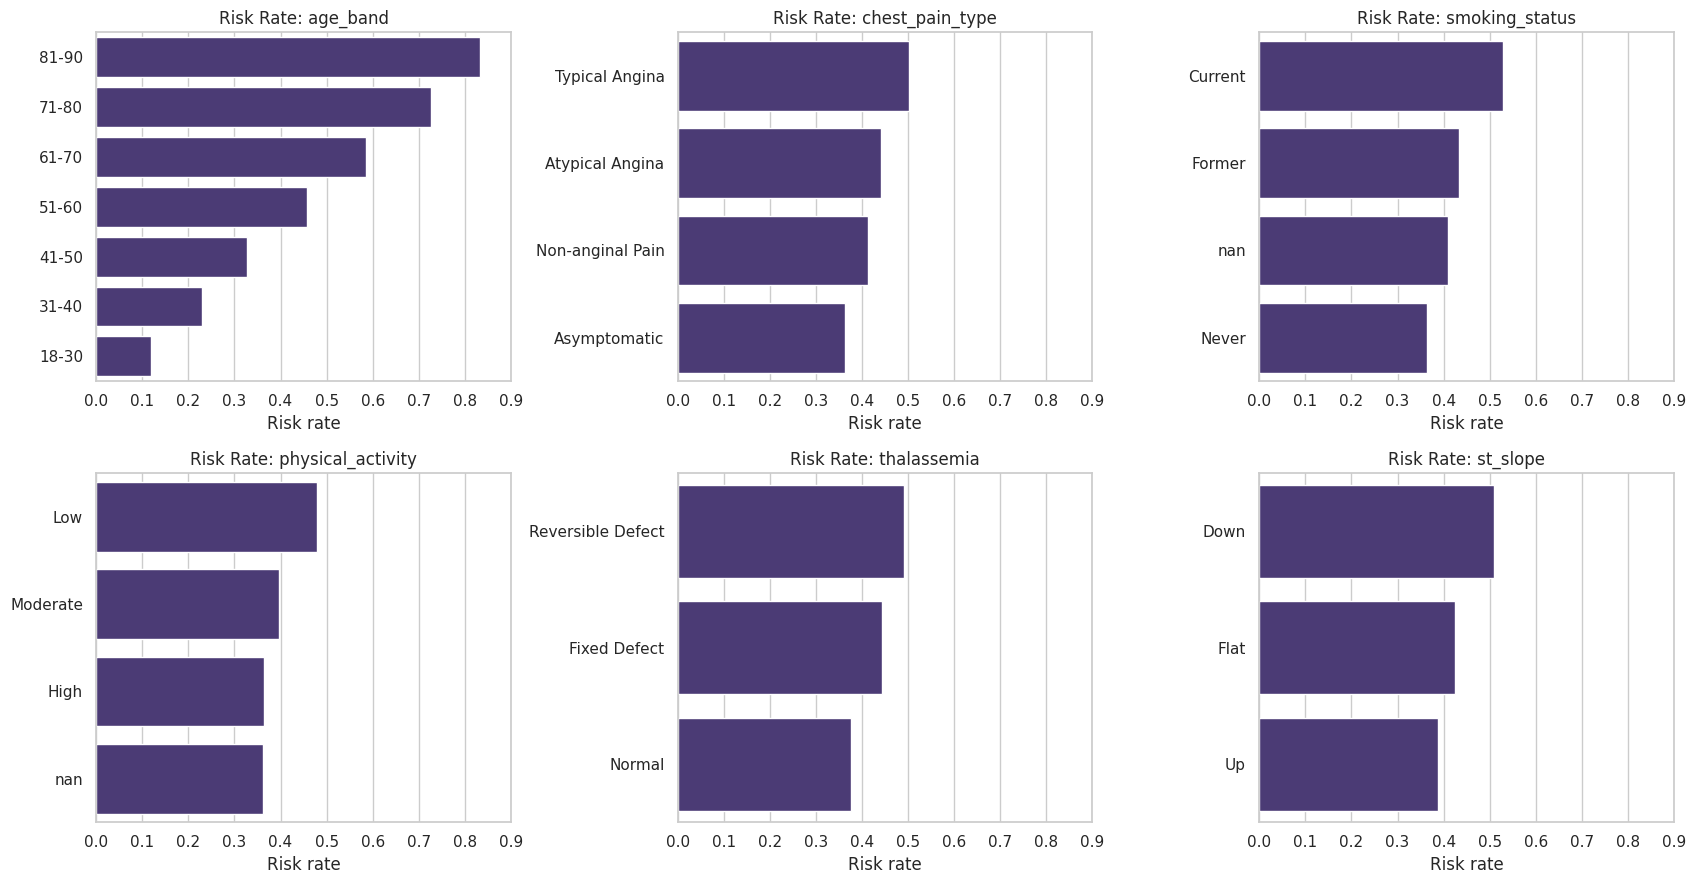

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(17, 9))
axes = axes.ravel()

for ax, feature in zip(axes, key_groups):
    rates = target_rate_table(df_eda, feature).reset_index()
    rates[feature] = rates[feature].astype(str)
    sns.barplot(data=rates, x="risk_rate", y=feature, ax=ax)
    ax.set_title(f"Risk Rate: {feature}")
    ax.set_xlabel("Risk rate")
    ax.set_ylabel("")
    ax.set_xlim(0, max(0.9, rates["risk_rate"].max() + 0.05))

plt.tight_layout()
plt.show()

## 6. Numeric Relationships

Correlations reveal signal and redundancy, not causality.

,count,mean,std,min,25%,50%,75%,max
patient_id,7000.0,3500.50,2020.87,1.0,1750.75,3500.5,5250.25,7000.0
age,7000.0,51.92,13.89,18.0,43.00,52.0,61.00,90.0
resting_bp,6720.0,116.45,13.20,80.0,107.00,116.0,125.00,162.0
cholesterol,6602.0,184.65,33.18,100.0,162.00,184.0,207.00,316.0
fasting_blood_sugar,6804.0,0.25,0.43,0.0,0.00,0.0,1.00,1.0
max_heart_rate,6721.0,173.94,15.13,115.0,164.00,174.0,184.00,210.0
exercise_angina,7000.0,0.32,0.47,0.0,0.00,0.0,1.00,1.0
oldpeak,6650.0,1.27,1.06,0.0,0.50,1.0,1.70,6.5
num_major_vessels,7000.0,0.75,0.99,0.0,0.00,0.0,1.00,3.0
bmi,6670.0,27.11,5.01,15.0,23.70,27.1,30.58,49.4


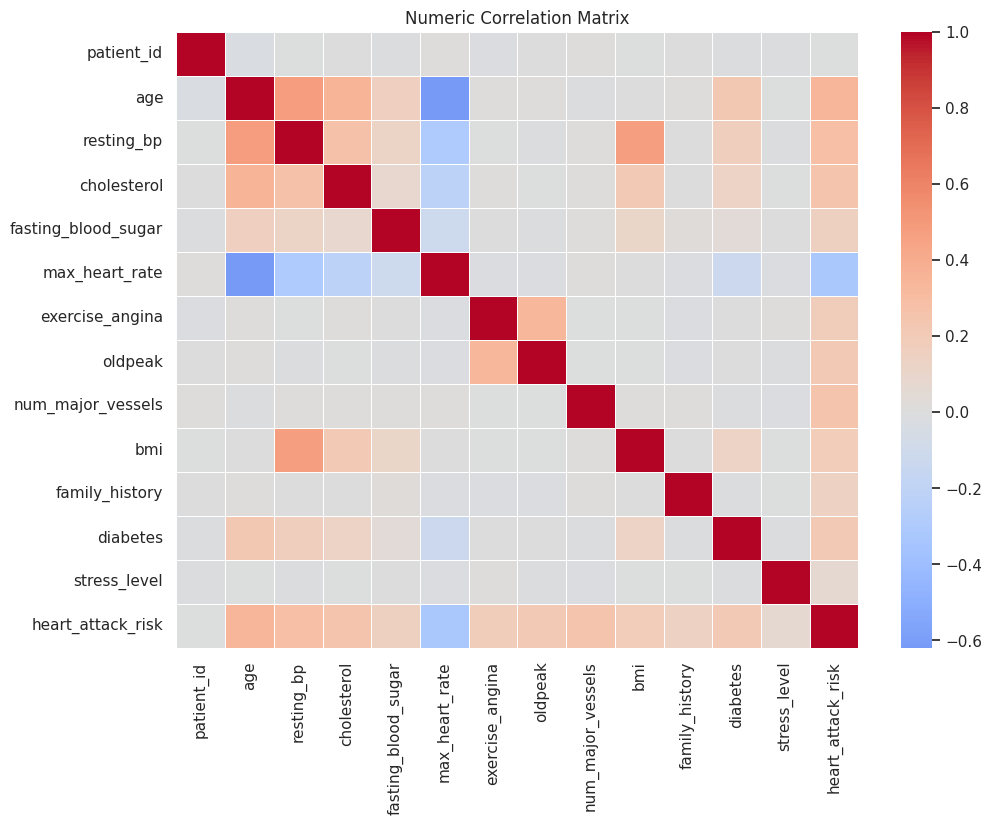

,corr_with_target
age,0.346
max_heart_rate,-0.324
resting_bp,0.286
cholesterol,0.250
num_major_vessels,0.249
diabetes,0.218
oldpeak,0.211
bmi,0.179
exercise_angina,0.175
fasting_blood_sugar,0.155


In [7]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

display(df[numeric_cols].describe().T.round(2))

corr = df[numeric_cols].corr()
plt.figure(figsize=(11, 8))
sns.heatmap(corr, cmap="coolwarm", center=0, linewidths=0.4)
plt.title("Numeric Correlation Matrix")
plt.show()

target_corr = (
    corr[TARGET]
    .drop([TARGET], errors="ignore")
    .sort_values(key=lambda s: s.abs(), ascending=False)
    .to_frame("corr_with_target")
)
display(target_corr.round(3))

## 7. Leakage Audit

Identifiers and row order must not carry predictive signal into the model.

In [8]:
leakage_checks = {}

if ID_COL in df:
    leakage_checks["id_unique"] = df[ID_COL].is_unique
    leakage_checks["id_target_corr"] = df[ID_COL].corr(df[TARGET])

    id_deciles = pd.qcut(df[ID_COL], 10, labels=False, duplicates="drop")
    id_target_rate = (
        df.assign(id_decile=id_deciles)
        .groupby("id_decile")[TARGET]
        .agg(rows="count", risk_rate="mean")
    )
    display(id_target_rate.round(3))

display(pd.Series(leakage_checks, name="value"))

print("Decision: drop patient_id and keep all preprocessing inside CV pipelines.")

,rows,risk_rate
id_decile,,
0,700,0.411
1,700,0.444
2,700,0.419
3,700,0.409
4,700,0.413
5,700,0.447
6,700,0.406
7,700,0.417
8,700,0.427


id_unique             True
id_target_corr   -0.004176
Name: value, dtype: object

Decision: drop patient_id and keep all preprocessing inside CV pipelines.


## 8. Feature Engineering

Add domain-inspired features without using the target.

In [9]:
class ClinicalFeatureBuilder(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()

        age = X["age"]
        resting_bp = X["resting_bp"]
        cholesterol = X["cholesterol"]
        max_hr = X["max_heart_rate"]
        bmi = X["bmi"]
        oldpeak = X["oldpeak"]

        X["hr_reserve_ratio"] = max_hr / (220 - age).clip(lower=1)
        X["age_x_cholesterol"] = age * cholesterol
        X["age_x_resting_bp"] = age * resting_bp
        X["oldpeak_x_angina"] = oldpeak * X["exercise_angina"]

        X["metabolic_risk_score"] = (
            X["diabetes"].fillna(0)
            + X["fasting_blood_sugar"].fillna(0)
            + (bmi >= 30).astype(float)
            + (cholesterol >= 200).astype(float)
            + (resting_bp >= 130).astype(float)
        )

        X["lifestyle_risk_score"] = (
            (X["smoking_status"] == "Current").astype(float)
            + (X["alcohol_consumption"] == "Heavy").astype(float)
            + (X["physical_activity"] == "Low").astype(float)
            + (X["stress_level"] >= 8).astype(float)
        )

        X["symptom_severity_score"] = (
            X["exercise_angina"].fillna(0)
            + (oldpeak >= 2).astype(float)
            + (X["st_slope"] == "Down").astype(float)
            + (X["chest_pain_type"] == "Typical Angina").astype(float)
        )

        X["age_band"] = pd.cut(
            age,
            bins=[17, 30, 40, 50, 60, 70, 80, 91],
            labels=["18-30", "31-40", "41-50", "51-60", "61-70", "71-80", "81-90"],
        ).astype("object")

        X["bmi_band"] = pd.cut(
            bmi,
            bins=[0, 18.5, 25, 30, np.inf],
            labels=["underweight", "normal", "overweight", "obese"],
        ).astype("object")

        X["bp_band"] = pd.cut(
            resting_bp,
            bins=[0, 120, 130, 140, np.inf],
            labels=["normal", "elevated", "stage_1", "stage_2"],
        ).astype("object")

        X["cholesterol_band"] = pd.cut(
            cholesterol,
            bins=[0, 200, 240, np.inf],
            labels=["desirable", "borderline", "high"],
        ).astype("object")

        return X

## 9. Leak-Free Pipeline

The transformer, imputer, encoder, scaler, and model are fitted only inside each fold.

In [10]:
feature_df = df.drop(columns=[TARGET])
if ID_COL in feature_df:
    feature_df = feature_df.drop(columns=[ID_COL])

y = df[TARGET].astype(int)
X = feature_df.copy()

base_numeric = X.select_dtypes(include=np.number).columns.tolist()
base_categorical = X.select_dtypes(exclude=np.number).columns.tolist()

engineered_numeric = base_numeric + [
    "hr_reserve_ratio",
    "age_x_cholesterol",
    "age_x_resting_bp",
    "oldpeak_x_angina",
    "metabolic_risk_score",
    "lifestyle_risk_score",
    "symptom_severity_score",
]

engineered_categorical = base_categorical + [
    "age_band",
    "bmi_band",
    "bp_band",
    "cholesterol_band",
]


def make_ohe():
    try:
        return OneHotEncoder(handle_unknown="ignore", min_frequency=10, sparse_output=False)
    except TypeError:
        try:
            return OneHotEncoder(handle_unknown="ignore", min_frequency=10, sparse=False)
        except TypeError:
            return OneHotEncoder(handle_unknown="ignore", sparse=False)


def make_preprocessor(use_engineered=True):
    numeric_features = engineered_numeric if use_engineered else base_numeric
    categorical_features = engineered_categorical if use_engineered else base_categorical

    numeric_pipe = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
        ("scaler", StandardScaler()),
    ])

    categorical_pipe = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
        ("onehot", make_ohe()),
    ])

    return ColumnTransformer(
        transformers=[
            ("num", numeric_pipe, numeric_features),
            ("cat", categorical_pipe, categorical_features),
        ],
        remainder="drop",
        sparse_threshold=0.0,
        verbose_feature_names_out=False,
    )


def make_pipeline(model, use_engineered=True):
    steps = []
    if use_engineered:
        steps.append(("features", ClinicalFeatureBuilder()))
    steps.extend([
        ("preprocess", make_preprocessor(use_engineered=use_engineered)),
        ("model", model),
    ])
    return Pipeline(steps)


print(f"Base numeric: {len(base_numeric)}")
print(f"Base categorical: {len(base_categorical)}")
print(f"Engineered numeric: {len(engineered_numeric)}")
print(f"Engineered categorical: {len(engineered_categorical)}")

Base numeric: 12
Base categorical: 8
Engineered numeric: 19
Engineered categorical: 12


## 10. Cross-Validated Model Comparison

Use stratified folds and metrics that work for imbalanced clinical screening.

In [11]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

scoring = {
    "roc_auc": "roc_auc",
    "avg_precision": "average_precision",
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "f1": "f1",
}

experiments = {
    "Logistic Regression | raw": make_pipeline(
        LogisticRegression(max_iter=3000, C=0.5, class_weight="balanced", solver="lbfgs"),
        use_engineered=False,
    ),
    "Logistic Regression | clinical features": make_pipeline(
        LogisticRegression(max_iter=3000, C=0.5, class_weight="balanced", solver="lbfgs"),
        use_engineered=True,
    ),
    "Random Forest | clinical features": make_pipeline(
        RandomForestClassifier(
            n_estimators=350,
            min_samples_leaf=8,
            class_weight="balanced_subsample",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
        use_engineered=True,
    ),
    "Extra Trees | clinical features": make_pipeline(
        ExtraTreesClassifier(
            n_estimators=400,
            min_samples_leaf=6,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
        use_engineered=True,
    ),
    "HistGradientBoosting | clinical features": make_pipeline(
        HistGradientBoostingClassifier(
            learning_rate=0.05,
            max_leaf_nodes=31,
            l2_regularization=0.10,
            random_state=RANDOM_STATE,
        ),
        use_engineered=True,
    ),
}

rows = []
for name, pipeline in experiments.items():
    scores = cross_validate(
        pipeline,
        X,
        y,
        cv=cv,
        scoring=scoring,
        n_jobs=1,
        error_score="raise",
    )
    row = {"model": name}
    for metric in scoring:
        values = scores[f"test_{metric}"]
        row[f"{metric}_mean"] = values.mean()
        row[f"{metric}_std"] = values.std()
    rows.append(row)

results = pd.DataFrame(rows).sort_values("roc_auc_mean", ascending=False)
display(results.round(4))

best_model_name = results.iloc[0]["model"]
best_pipeline = experiments[best_model_name]
print(f"Best by ROC-AUC: {best_model_name}")

,model,roc_auc_mean,roc_auc_std,avg_precision_mean,avg_precision_std,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,f1_mean,f1_std
0,Logistic Regression | raw,0.8724,0.0102,0.8386,0.0126,0.7894,0.0078,0.7885,0.0090,0.7573,0.0108
1,Logistic Regression | clinical features,0.8714,0.0093,0.8369,0.0119,0.7880,0.0080,0.7871,0.0087,0.7558,0.0102
4,HistGradientBoosting | clinical features,0.8582,0.0079,0.8149,0.0094,0.7820,0.0123,0.7716,0.0134,0.7313,0.0169
3,Extra Trees | clinical features,0.8442,0.0078,0.7987,0.0095,0.7629,0.0080,0.7598,0.0078,0.7241,0.0088
2,Random Forest | clinical features,0.8407,0.0099,0.7936,0.0072,0.7611,0.0080,0.7564,0.0085,0.7187,0.0101


Best by ROC-AUC: Logistic Regression | raw


## 11. Threshold Tuning

A clinical screen often needs a lower threshold than `0.50` to reduce missed high-risk cases.

In [12]:
def metric_row(y_true, proba, threshold):
    pred = (proba >= threshold).astype(int)
    return {
        "threshold": threshold,
        "roc_auc": roc_auc_score(y_true, proba),
        "avg_precision": average_precision_score(y_true, proba),
        "brier": brier_score_loss(y_true, proba),
        "accuracy": accuracy_score(y_true, pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, pred),
        "precision": precision_score(y_true, pred),
        "recall": recall_score(y_true, pred),
        "f1": f1_score(y_true, pred),
    }


oof_proba = cross_val_predict(
    best_pipeline,
    X,
    y,
    cv=cv,
    method="predict_proba",
    n_jobs=1,
)[:, 1]

precision, recall, thresholds = precision_recall_curve(y, oof_proba)
f1_scores = 2 * precision * recall / (precision + recall + 1e-12)
best_idx = np.argmax(f1_scores[:-1])
best_threshold = thresholds[best_idx]

threshold_report = pd.DataFrame([
    metric_row(y, oof_proba, 0.50),
    metric_row(y, oof_proba, best_threshold),
], index=["default_0.50", "best_f1"])

display(threshold_report.round(4))

,threshold,roc_auc,avg_precision,brier,accuracy,balanced_accuracy,precision,recall,f1
default_0.50,0.500,0.8724,0.8385,0.1458,0.7894,0.7885,0.7337,0.7827,0.7574
best_f1,0.429,0.8724,0.8385,0.1458,0.7779,0.7853,0.6975,0.8320,0.7588


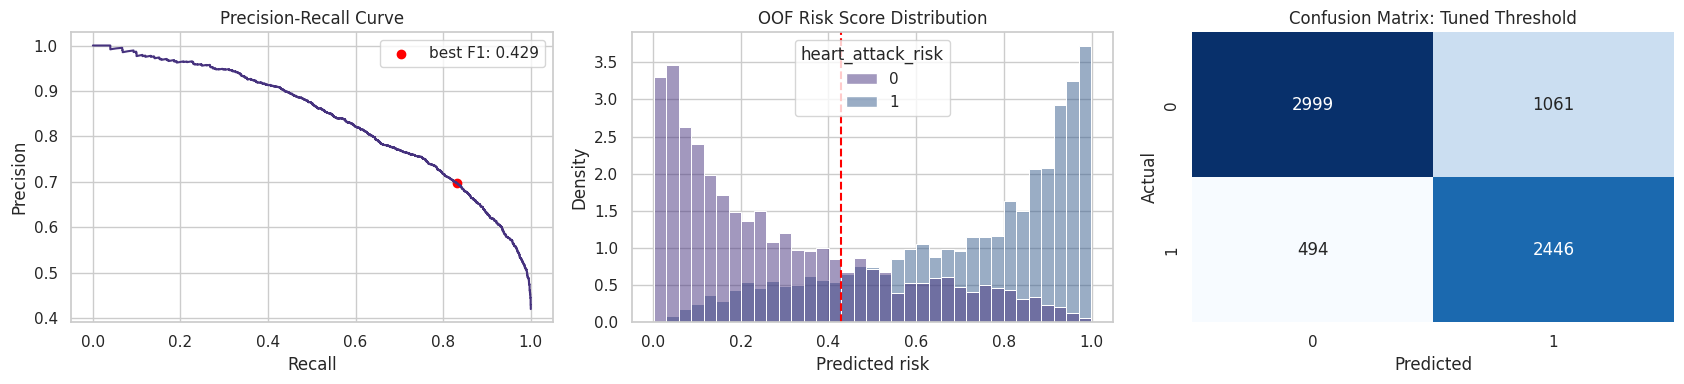

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4))

axes[0].plot(recall, precision)
axes[0].scatter(recall[best_idx], precision[best_idx], color="red", label=f"best F1: {best_threshold:.3f}")
axes[0].set_title("Precision-Recall Curve")
axes[0].set_xlabel("Recall")
axes[0].set_ylabel("Precision")
axes[0].legend()

sns.histplot(x=oof_proba, hue=y, bins=35, stat="density", common_norm=False, ax=axes[1])
axes[1].axvline(best_threshold, color="red", linestyle="--")
axes[1].set_title("OOF Risk Score Distribution")
axes[1].set_xlabel("Predicted risk")

cm = confusion_matrix(y, (oof_proba >= best_threshold).astype(int))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[2])
axes[2].set_title("Confusion Matrix: Tuned Threshold")
axes[2].set_xlabel("Predicted")
axes[2].set_ylabel("Actual")

plt.tight_layout()
plt.show()

## 12. Explainability

Use model coefficients when available and permutation importance for original input features.

threshold            0.4290
roc_auc              0.8686
avg_precision        0.8347
brier                0.1470
accuracy             0.7714
balanced_accuracy    0.7760
precision            0.6976
recall               0.8044
f1                   0.7472
Name: holdout_diagnostic, dtype: float64

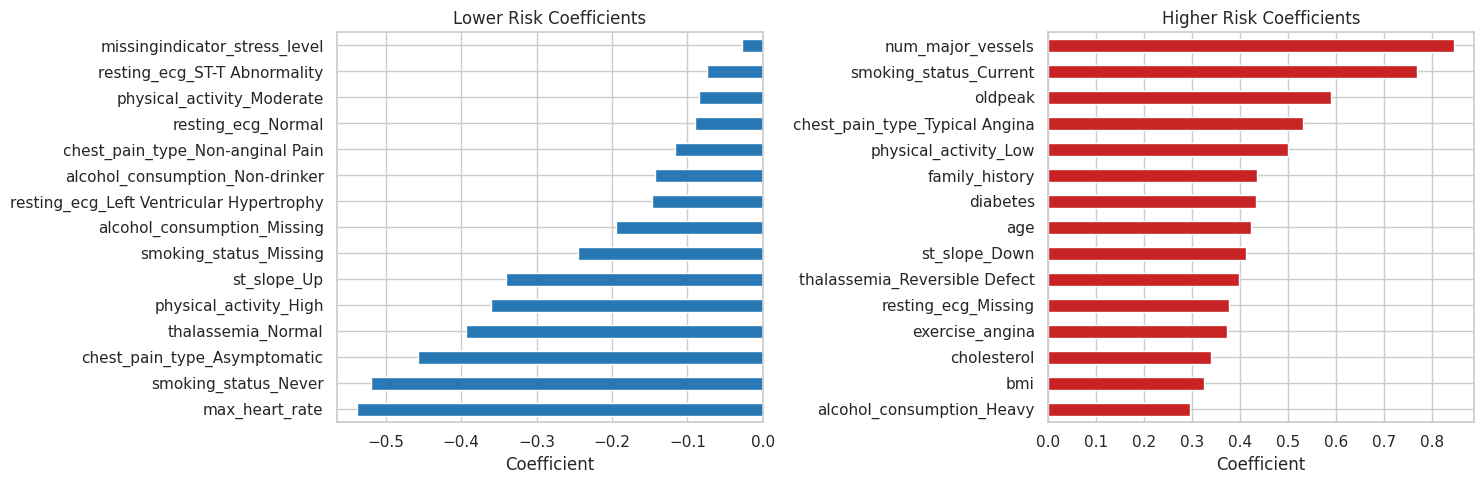

,coefficient
max_heart_rate,-0.5375
smoking_status_Never,-0.5192
chest_pain_type_Asymptomatic,-0.4567
thalassemia_Normal,-0.3934
physical_activity_High,-0.3604
st_slope_Up,-0.3403
smoking_status_Missing,-0.2449
alcohol_consumption_Missing,-0.1948
resting_ecg_Left Ventricular Hypertrophy,-0.1467
alcohol_consumption_Non-drinker,-0.1435


In [14]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE,
)

diagnostic_model = clone(best_pipeline)
diagnostic_model.fit(X_train, y_train)

valid_proba = diagnostic_model.predict_proba(X_valid)[:, 1]
display(pd.Series(metric_row(y_valid, valid_proba, best_threshold), name="holdout_diagnostic").round(4))

fitted_model = diagnostic_model.named_steps["model"]

if hasattr(fitted_model, "coef_"):
    feature_names = diagnostic_model.named_steps["preprocess"].get_feature_names_out()
    coefs = pd.Series(fitted_model.coef_.ravel(), index=feature_names).sort_values()

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    coefs.head(15).plot(kind="barh", ax=axes[0], color="#2878B5")
    axes[0].set_title("Lower Risk Coefficients")
    axes[0].set_xlabel("Coefficient")

    coefs.tail(15).plot(kind="barh", ax=axes[1], color="#C82423")
    axes[1].set_title("Higher Risk Coefficients")
    axes[1].set_xlabel("Coefficient")

    plt.tight_layout()
    plt.show()

    display(pd.concat([coefs.head(15), coefs.tail(15)]).to_frame("coefficient").round(4))

,feature,importance_mean,importance_std
11,num_major_vessels,0.0612,0.0064
7,max_heart_rate,0.0405,0.0044
9,oldpeak,0.0342,0.0022
17,family_history,0.0232,0.0026
0,age,0.0216,0.0024
18,diabetes,0.0191,0.0023
8,exercise_angina,0.0169,0.0023
14,smoking_status,0.0168,0.0027
4,cholesterol,0.0109,0.0021
12,thalassemia,0.0085,0.0018


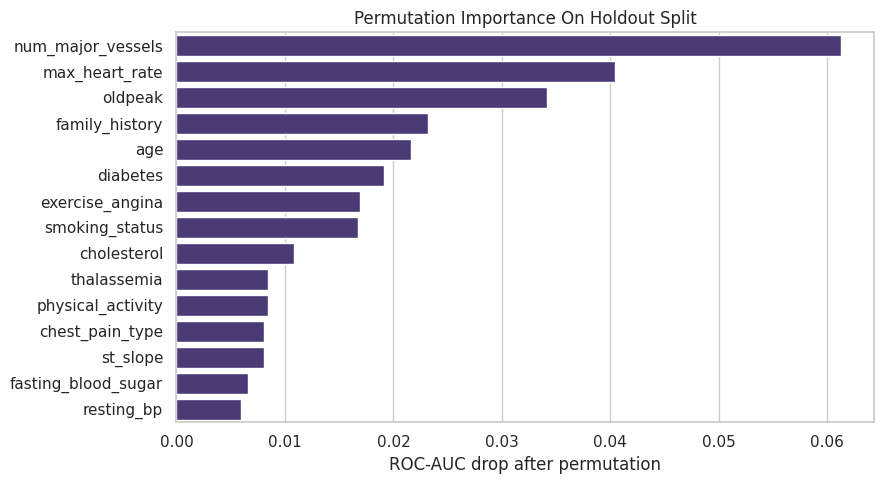

In [15]:
perm = permutation_importance(
    diagnostic_model,
    X_valid,
    y_valid,
    scoring="roc_auc",
    n_repeats=8,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

perm_df = (
    pd.DataFrame({
        "feature": X_valid.columns,
        "importance_mean": perm.importances_mean,
        "importance_std": perm.importances_std,
    })
    .sort_values("importance_mean", ascending=False)
    .head(15)
)

display(perm_df.round(4))

plt.figure(figsize=(9, 5))
sns.barplot(data=perm_df, x="importance_mean", y="feature")
plt.title("Permutation Importance On Holdout Split")
plt.xlabel("ROC-AUC drop after permutation")
plt.ylabel("")
plt.tight_layout()
plt.show()

## 13. Final Scoring Utility

Fit once on all available data and expose a small prediction helper.

In [16]:
final_model = clone(best_pipeline)
final_model.fit(X, y)


def assign_risk_band(probability):
    if probability < 0.33:
        return "low"
    if probability < 0.66:
        return "medium"
    return "high"


def predict_heart_attack_risk(records, threshold=best_threshold):
    records = pd.DataFrame(records).copy()
    if ID_COL in records:
        records = records.drop(columns=[ID_COL])

    proba = final_model.predict_proba(records)[:, 1]
    return pd.DataFrame({
        "predicted_probability": proba,
        "risk_band": [assign_risk_band(p) for p in proba],
        "predicted_label": (proba >= threshold).astype(int),
    })


example_records = X.sample(5, random_state=RANDOM_STATE)
display(example_records)
display(predict_heart_attack_risk(example_records))

,age,gender,chest_pain_type,resting_bp,cholesterol,fasting_blood_sugar,resting_ecg,max_heart_rate,exercise_angina,oldpeak,st_slope,num_major_vessels,thalassemia,bmi,smoking_status,alcohol_consumption,physical_activity,family_history,diabetes,stress_level
6500,69,Female,Non-anginal Pain,139.0,232.0,1.0,ST-T Abnormality,159.0,0,2.8,Flat,0,Normal,30.0,Never,Non-drinker,Moderate,0,0,10.0
2944,57,Male,Atypical Angina,130.0,210.0,0.0,Normal,163.0,0,0.7,Down,1,Normal,35.0,Current,Non-drinker,Moderate,0,0,3.0
2024,18,Female,Asymptomatic,80.0,160.0,0.0,Normal,191.0,1,1.0,Up,1,Normal,22.2,Never,Moderate,Moderate,0,0,10.0
263,38,Female,Typical Angina,103.0,185.0,0.0,Normal,NaN,1,1.1,Down,0,Normal,23.8,Never,Heavy,High,1,1,9.0
4350,23,Female,Typical Angina,97.0,229.0,0.0,Normal,204.0,0,0.7,Down,0,Normal,27.9,Never,NaN,Moderate,0,1,10.0


,predicted_probability,risk_band,predicted_label
0,0.809960,high,1
1,0.755443,high,1
2,0.013487,low,0
3,0.630438,medium,1
4,0.069211,low,0
